# AI-Based Prediction of Airfoil Self-Noise for Faster Aerodynamic Design

This project develops and compares two machine learning models—Random Forest (RF) and Artificial Neural Network (ANN)—to predict airfoil self-noise using NASA experimental data.

Traditional aerodynamic noise analysis requires computationally expensive simulations or wind tunnel testing. This approach uses AI to provide faster approximations, enabling quicker design iterations.

Both models are evaluated, and the best-performing model is selected based on accuracy and reliability.

**Goal:** Reduce time and cost in early-stage aerodynamic noise estimation.

In [1]:
# Importing libraries for data loading, EDA, preprocessing, model training, evaluation, and deep learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import joblib

## Data Retrival

In [2]:
df = pd.read_csv('airfoilselfnoise.csv')
df.head()

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


In [3]:
# Renaming columns
df.rename(columns={'f':'frequency','alpha':"angle of attack", 'c':'chord length','U_infinity':'free-stream velocity','delta':'displacement thickness','SSPL':'scaled sound pressure level'}, inplace =True)
df.columns

Index(['frequency', 'angle of attack', 'chord length', 'free-stream velocity',
       'displacement thickness', 'scaled sound pressure level'],
      dtype='object')

## Exploratory Data Analysis

In [4]:
df.shape

(1503, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   frequency                    1503 non-null   int64  
 1   angle of attack              1503 non-null   float64
 2   chord length                 1503 non-null   float64
 3   free-stream velocity         1503 non-null   float64
 4   displacement thickness       1503 non-null   float64
 5   scaled sound pressure level  1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [6]:
df.describe()

,frequency,angle of attack,chord length,free-stream velocity,displacement thickness,scaled sound pressure level
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


In [7]:
df[['frequency', 'angle of attack', 'chord length', 'free-stream velocity',
       'displacement thickness', 'scaled sound pressure level']].skew()

frequency                      2.137084
angle of attack                0.689164
chord length                   0.457457
free-stream velocity           0.235852
displacement thickness         1.702165
scaled sound pressure level   -0.418952
dtype: float64

### Outlier Detection
We examined all input features for skewness and outliers.
Features with significant skew or extreme values are:

. Frequency

. Displacement Thickness

. Angle of Attack (mild skew)

These features may require transformation or scaling to improve model performance.

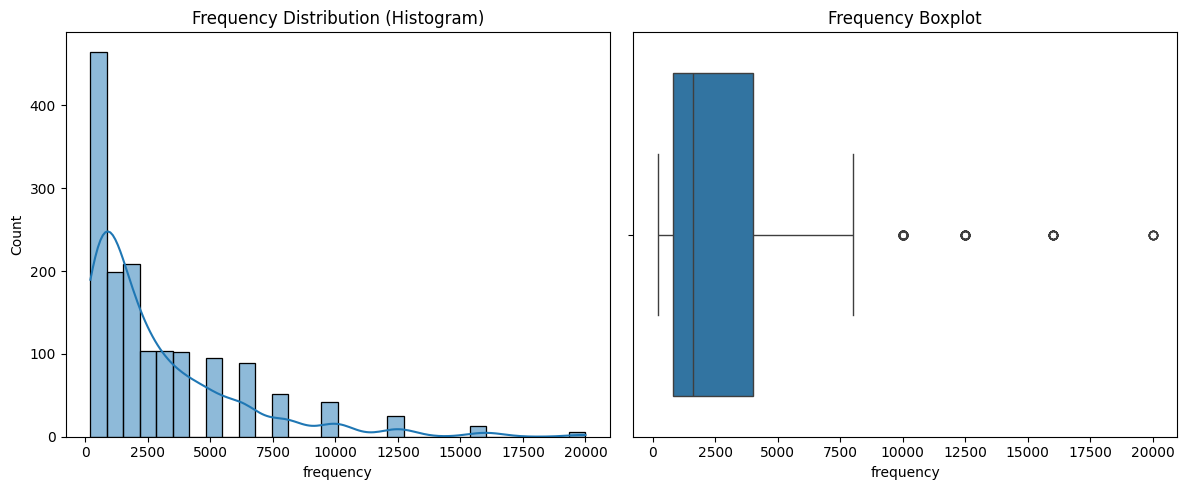

In [8]:
# Visualizing distribution of 'frequency' feature using histogram and boxplot
# Set up the figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram on the left
sns.histplot(df['frequency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Frequency Distribution (Histogram)')

# Boxplot on the right
sns.boxplot(x=df['frequency'], ax=axes[1])
axes[1].set_title('Frequency Boxplot')

plt.tight_layout()
plt.show()

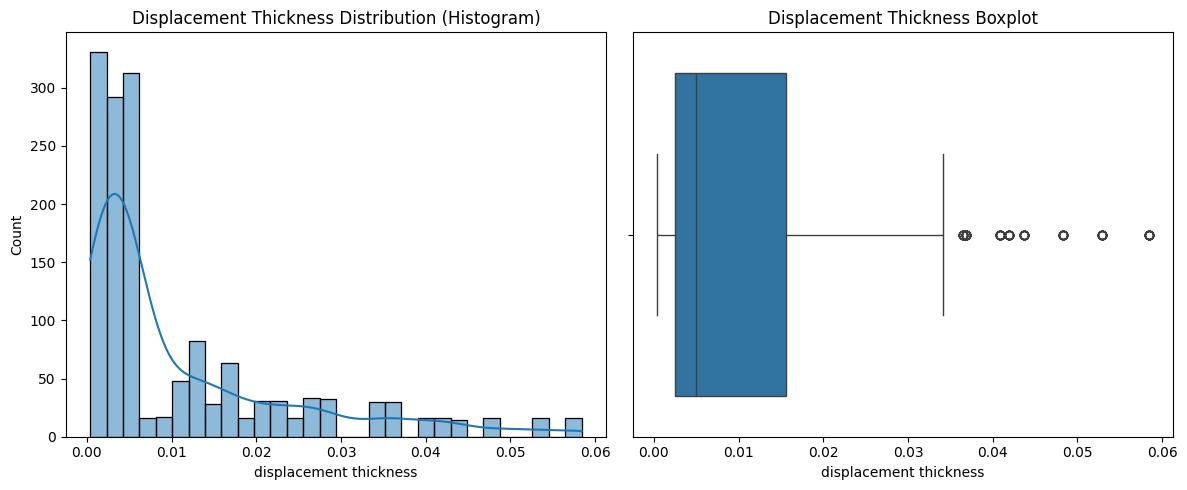

In [9]:
# Visualizing distribution of 'distribution feature' feature using histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['displacement thickness'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Displacement Thickness Distribution (Histogram)')

sns.boxplot(x=df['displacement thickness'], ax=axes[1])
axes[1].set_title('Displacement Thickness Boxplot')

plt.tight_layout()
plt.show()

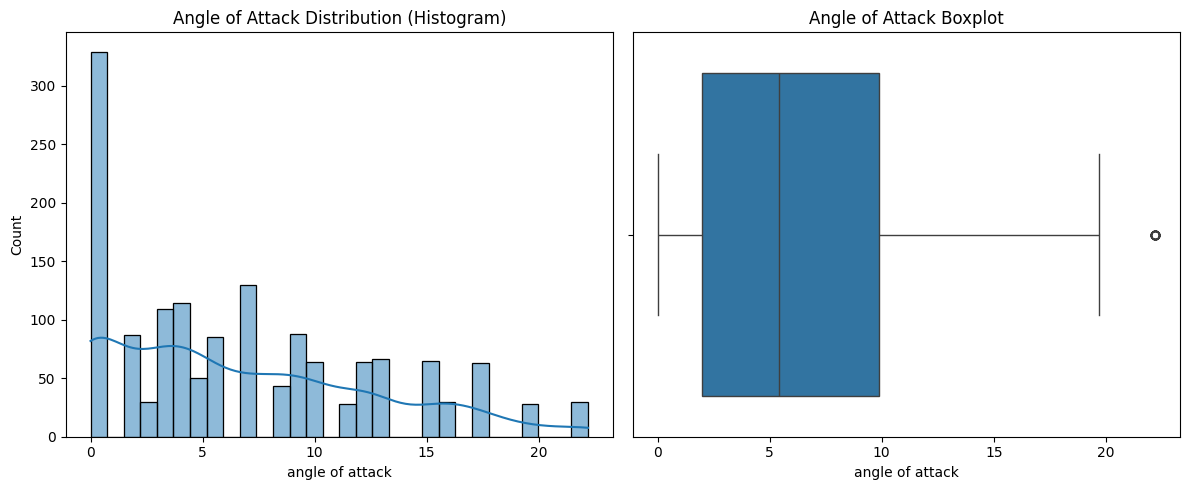

In [10]:
# Visualizing distribution of 'angle of attack' feature using histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram on the left
sns.histplot(df['angle of attack'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Angle of Attack Distribution (Histogram)')

# Boxplot on the right
sns.boxplot(x=df['angle of attack'], ax=axes[1])
axes[1].set_title('Angle of Attack Boxplot')

plt.tight_layout()
plt.show()

### Correlation Analysis
We analyze feature correlations to identify relationships, multicollinearity, and patters with the target variable

In [11]:
df.corr()['scaled sound pressure level'].sort_values(ascending =False)

scaled sound pressure level    1.000000
free-stream velocity           0.125103
angle of attack               -0.156108
chord length                  -0.236162
displacement thickness        -0.312670
frequency                     -0.390711
Name: scaled sound pressure level, dtype: float64

#### Feature-Target Correlation Analysis

We computed the linear correlation between input features and the target (Scaled Sound Pressure Level).
Most features show moderate to low correlation, with frequency having the strongest relationship **(-0.39)**.
Low linear correlation is natural in physics-based datasets where relationships can be nonlinear.

### Exploring target feature: Airfoil sound pressure level distribution

<Axes: xlabel='scaled sound pressure level', ylabel='Count'>

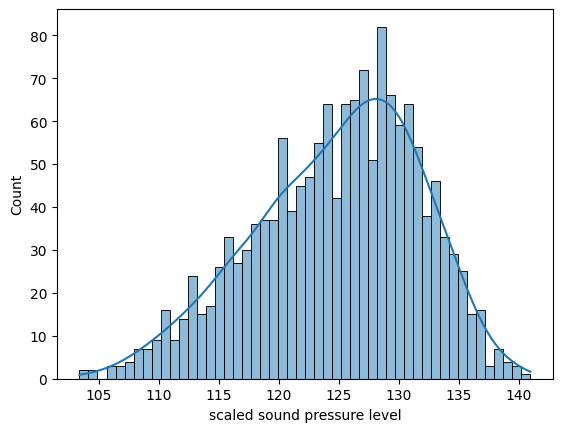

In [12]:
sns.histplot(df['scaled sound pressure level'], bins=50, kde=True)

In [13]:
 df['scaled sound pressure level'].max()

np.float64(140.987)

## Data Preprocessing

#### Preprocessing Note

Preprocessing for Random Forest is performed inside a scalable pipeline to ensure reproducibility and production-readiness.  
For the ANN, preprocessing is handled separately in the dataset loader to accommodate model-specific requirements.  
Any preprocessing done now# Apply log transformation to reduce skewness and stabilize variance for modeling is only for exploration and understanding—to see how features affect the data and target—so we can make informed decisions.

In [14]:
# Apply log transformation to reduce skewness and stabilize variance for modeling
df['frequency_log'] = np.log1p(df['frequency'])
df['displacement_thickness_log'] = np.log1p(df['displacement thickness'])
df['angle_of_attack_log'] = np.log1p(df['angle of attack'])  


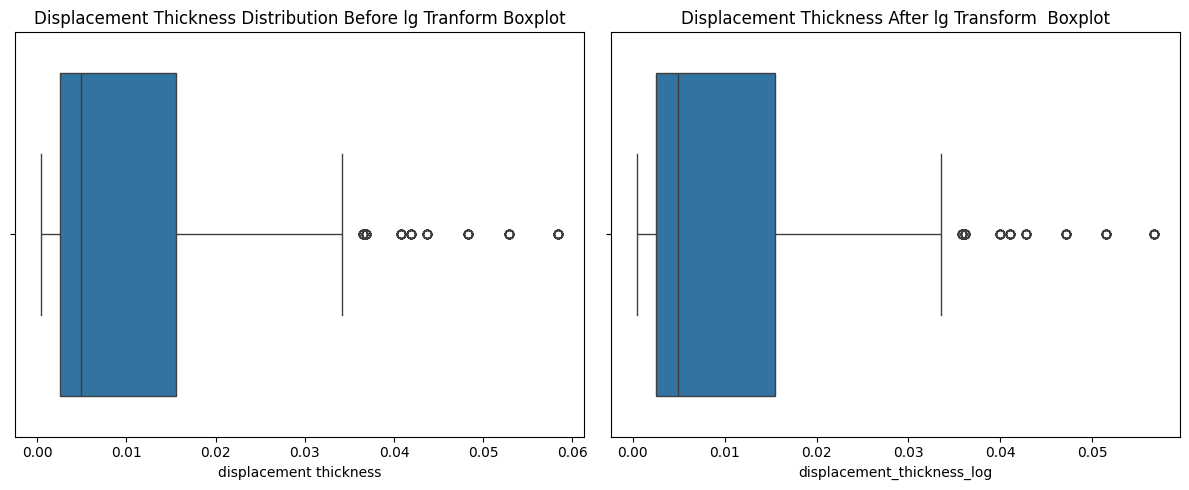

In [15]:
# Visual comparison of 'displacement thickness' before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(x=df['displacement thickness'], ax=axes[0])
axes[0].set_title('Displacement Thickness Distribution Before lg Tranform Boxplot')


sns.boxplot(x=df['displacement_thickness_log'], ax=axes[1])
axes[1].set_title('Displacement Thickness After lg Transform  Boxplot')

plt.tight_layout()
plt.show()

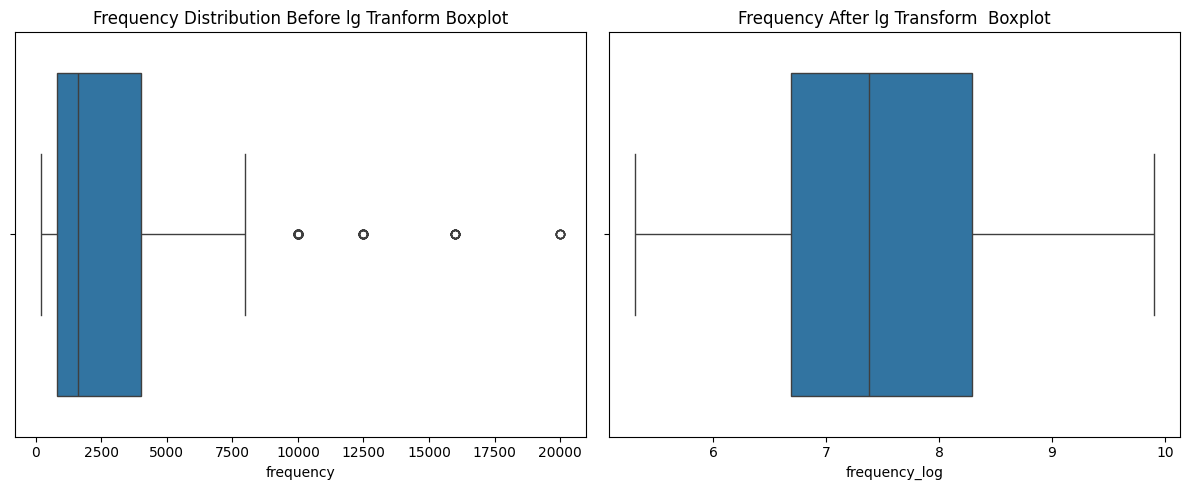

In [16]:
# Visual comparison of 'frequency' before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.boxplot(x=df['frequency'], ax=axes[0])
axes[0].set_title('Frequency Distribution Before lg Tranform Boxplot')


sns.boxplot(x=df['frequency_log'], ax=axes[1])
axes[1].set_title('Frequency After lg Transform  Boxplot')

plt.tight_layout()
plt.show()

In [17]:
df[['frequency_log', 'displacement_thickness_log', 'angle_of_attack_log']].skew()

frequency_log                -0.030278
displacement_thickness_log    1.677049
angle_of_attack_log          -0.539446
dtype: float64

Log transformation of **Frequency** and **Angle of Attack** reduces skewness and effectively removes extreme outliers.
**Displacement Thickness**, however, still contains extreme points after log transform; these will be removed using **percentile-based clipping**.

In [18]:
# Cut displacement thickness outliers and create new column
# Clip extreme outliers (keep 1st to 99th percentile)
lower = df['displacement_thickness_log'].quantile(0.01)
upper = df['displacement_thickness_log'].quantile(0.99)

df['displacement_thickness_log_clipped'] = df['displacement_thickness_log'].clip(lower, upper, inplace=False)

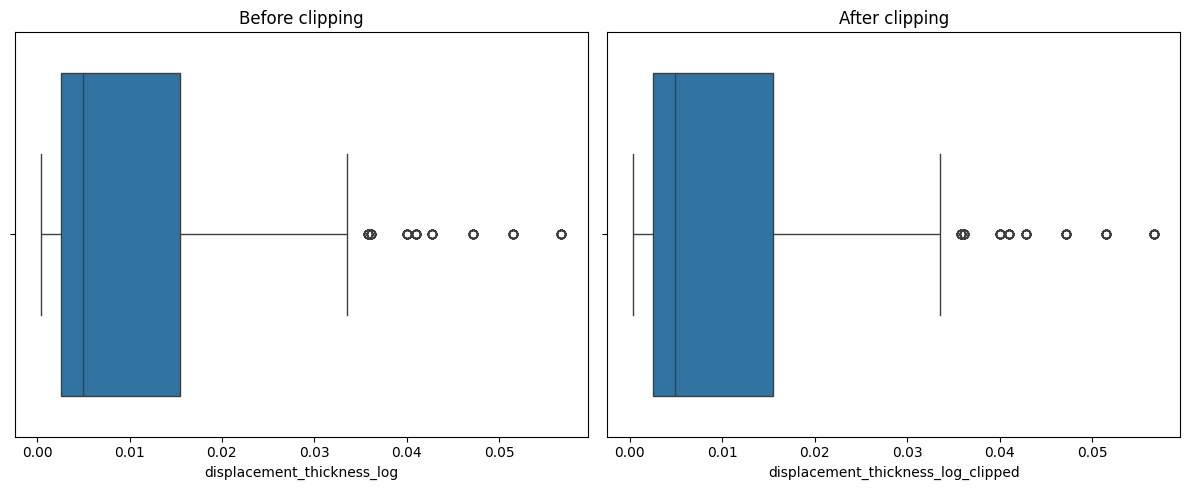

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df['displacement_thickness_log'], ax=axes[0]).set_title('Before clipping')
sns.boxplot(x=df['displacement_thickness_log_clipped'], ax=axes[1]).set_title('After clipping')
plt.tight_layout()
plt.show()

Displacement Thickness is highly skewed. Even after log transform and clipping, the boxplot flags many points as outliers due to the extreme range of values.
This is expected in physics datasets. The transformations reduce the effect of extreme values for model learning, so we proceed with the pipeline.

##  Model 1: Random Forest

In [20]:
drop_cols = ['scaled sound pressure level', 'frequency_log', 'displacement_thickness_log', 
             'displacement_thickness_log_clipped', 'angle_of_attack_log']
X = df.drop(columns=drop_cols)
y = df['scaled sound pressure level']

In [21]:

# features we decided to log-transform due to skewness
log_features = ['frequency', 'displacement thickness', 'angle of attack']

# Columns that remain as-is (no log needed)
other_features = [col for col in X.columns if col not in log_features]


# Log transform using FunctionTransformer
log_transformer = FunctionTransformer(np.log1p, validate=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_transformer, log_features),
        ('scale', StandardScaler(), other_features)
    ]
)

### Training

In [22]:
# Create the pipeline with Random Forest
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=250,      # slightly larger forest for stability
        max_depth=12,          # reasonable depth to prevent overfitting
        min_samples_split=5,   # require at least 5 samples to split
        min_samples_leaf=2,    # require at least 2 samples in leaves
        random_state=42,
        n_jobs=-1
    ))
])

In [23]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Evaluation

In [25]:
y_pred = pipeline.predict(X_test)

In [26]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R²: 0.9077
MSE: 4.6233
RMSE: 2.1502
MAE: 1.5744


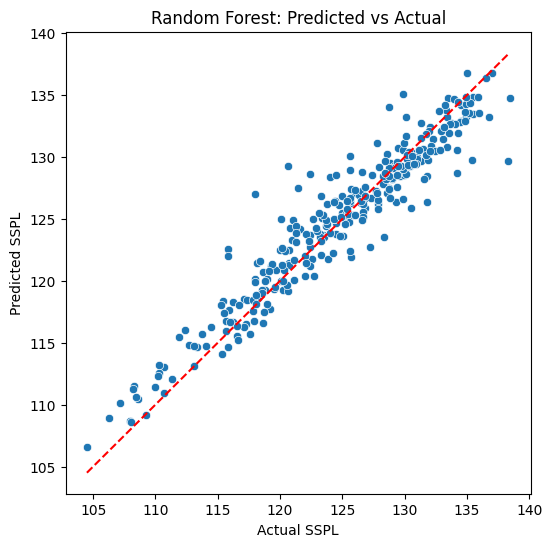

In [27]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual SSPL")
plt.ylabel("Predicted SSPL")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

## Random Forest Evaluation

After training the Random Forest model, we assess its predictive performance on the test set:

- **R² ≈ 0.90+**
- **Error Metrics:** MSE, RMSE, MAE are low
- Predictions closely match actual values

### Visual Analysis
- Scatter plot shows points tightly clustered around the ideal diagonal line.
- Indicates strong predictive accuracy and model stability.

> Interpretation: Random Forest effectively captures the patterns in this structured, tabular dataset, making it a strong candidate for engineering use.

## Model 2: Artificial Neural Network

In [28]:
torch.manual_seed(42)

### Scaling features and Converting to tensors

In [29]:
# Scale features
scaler = StandardScaler()

# Example: log transform first (only for selected columns)
log_features = ['frequency', 'displacement thickness', 'angle of attack']

X_train[log_features] = np.log1p(X_train[log_features])
X_test[log_features] = np.log1p(X_test[log_features])

# Fit only on train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1,1))

In [30]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

### Creating Dataset & DataLoader and Defining ANN class

In [31]:
class CustomDataset(Dataset):
    def __init__(self, features,labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self,index):
        return self.features[index], self.labels[index]  

In [32]:
train_dataset = CustomDataset(X_train_tensor,y_train_tensor)
test_dataset = CustomDataset(X_test_tensor,y_test_tensor)

In [33]:
# Creating train and test loader
train_loader = DataLoader(train_dataset, batch_size = 16 ,shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle =False)

In [34]:
# Defining nn class
class MYNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features,8),
            nn.ReLU(),
            nn.Linear(8,8),
            nn.ReLU(),
            nn.Linear(8,6),
            nn.ReLU(),
            nn.Linear(6,1)
        )

    def forward(self,x):

        return self.model(x)    

### Training

In [35]:
# Set learning rate and epochs
epochs = 100
lr =0.001

In [36]:
# Instatiate the model
model = MYNN(X_train.shape[1])

# Loss criterion
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr = lr)

In [37]:
# Training Loop
for epoch in range(epochs):
    total_epoch_loss =0 
    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)

        loss = criterion(outputs,batch_labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_epoch_loss +=loss.item()
    avg_loss = total_epoch_loss/len(train_loader)

    print(f'Epoch: {epoch+1}, Loss: {avg_loss}')

Epoch: 1, Loss: 1.0291605535894632
Epoch: 2, Loss: 1.0313701955111403
Epoch: 3, Loss: 1.013106689077655
Epoch: 4, Loss: 1.0110456137672852
Epoch: 5, Loss: 1.0211243484365313
Epoch: 6, Loss: 1.0015352963911075
Epoch: 7, Loss: 1.0526735476757352
Epoch: 8, Loss: 1.0126463723810095
Epoch: 9, Loss: 1.0174941687207473
Epoch: 10, Loss: 1.0049823052004765
Epoch: 11, Loss: 1.0042356425210048
Epoch: 12, Loss: 1.00051984739931
Epoch: 13, Loss: 0.9913923715878474
Epoch: 14, Loss: 0.9945378519202533
Epoch: 15, Loss: 0.997670925761524
Epoch: 16, Loss: 0.9896800347456807
Epoch: 17, Loss: 0.9929639014758562
Epoch: 18, Loss: 0.9954883060172984
Epoch: 19, Loss: 0.9945272199417415
Epoch: 20, Loss: 0.988705829570168
Epoch: 21, Loss: 0.9829962053581288
Epoch: 22, Loss: 1.0166075178667118
Epoch: 23, Loss: 0.9813040420413017
Epoch: 24, Loss: 0.9873657485372141
Epoch: 25, Loss: 0.9794850700387829
Epoch: 26, Loss: 0.9811779519445017
Epoch: 27, Loss: 1.004218484226026
Epoch: 28, Loss: 0.9957039854244182
Epoch: 

### Evaluation

In [38]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)

In [39]:
y_pred = scaler.inverse_transform(y_pred.numpy())
y_true = scaler.inverse_transform(y_test_tensor.numpy())

In [40]:
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.4998137354850769
MSE: 25.058616638183594
RMSE: 5.005858231930224
MAE: 3.8228116035461426


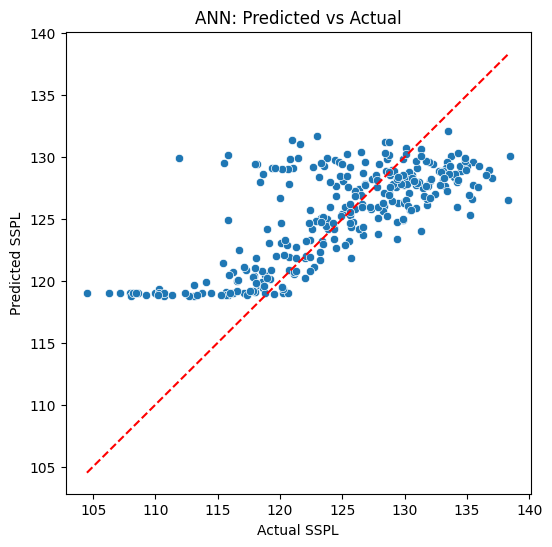

In [41]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_true.flatten(), y=y_pred.flatten())

# ideal line
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.xlabel("Actual SSPL")
plt.ylabel("Predicted SSPL")
plt.title("ANN: Predicted vs Actual")
plt.show()

## Artificial Neural Network Evaluation

Next, the ANN model is trained and evaluated on the same dataset:

- **R² ≈ 0.50**
- MSE ≈ 25.06, RMSE ≈ 5.01, MAE ≈ 3.82
- Predictions show greater variance compared to Random Forest

### Visual Analysis
- Scatter plot shows points more dispersed around the diagonal line.
- Indicates less stable predictions and weaker generalization.

> Interpretation: ANN underperforms on this small tabular dataset, as deep learning typically requires larger data volumes to achieve optimal performance. While technically correct, ANN is not ideal for this problem.

# 🔹 Model Comparison and Engineering Decision

| Model           | R²    | MSE   | RMSE  | MAE   | Engineering Suitability |
|-----------------|-------|-------|-------|-------|------------------------|
| Random Forest   | 0.90+ | 4.62  | 2.15  | 1.57  | ✅ Preferred for deployment, stable, interpretable |
| ANN             | 0.50  | 25.06 | 5.01  | 3.82 | ❌ Not suitable for small tabular dataset |

### Key Takeaways

1. **Model Selection Matters:** Structured/tabular data favors tree-based models like Random Forest over ANN for reliability and accuracy.
2. **Engineering Impact:** Random Forest predictions can accelerate noise estimation for airfoil design, potentially reducing reliance on costly simulations.
3. **Decision Rationale:** Despite testing ANN, Random Forest is chosen due to higher performance, lower error, and practical engineering applicability.

> 🔑 Overall: The final pipeline demonstrates a full engineering workflow—data acquisition → preprocessing → model training → evaluation → decision—highlighting practical AI application in engineering problems.

### Save Final Model (Random Forest for Deployment)

In [42]:
# save full pipeline (preprocessing + RF model)
joblib.dump(pipeline, "random_forest_pipeline.pkl")

['random_forest_pipeline.pkl']